In [1]:
import os
import pickle

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.io import read_image

In [2]:
nerv_save_dir = '../plotting_source_data/supplementary/NeRV/B-representation_is_distributed'
mlp_save_dir = '../plotting_source_data/supplementary/MLP/B-representation_is_distributed'

nerv_per_vid_num_pixels_with_meaningful_contrib = pickle.load(open(f'{nerv_save_dir}/per_vid_num_pixels_with_meaningful_contrib.pkl', 'rb'))
nerv_per_vid_num_kernels_with_meaningful_contrib = pickle.load(open(f'{nerv_save_dir}/per_vid_num_kernels_with_meaningful_contrib.pkl', 'rb'))

mlp_per_vid_num_pixels_with_meaningful_contrib = pickle.load(open(f'{mlp_save_dir}/per_vid_num_pixels_with_meaningful_contrib.pkl', 'rb'))
mlp_per_vid_num_kernels_with_meaningful_contrib = pickle.load(open(f'{mlp_save_dir}/per_vid_num_kernels_with_meaningful_contrib.pkl', 'rb'))

nerv_per_vid_sorted_contribs_per_layer = pickle.load(open(f'{nerv_save_dir}/per_vid_sorted_contribs_per_layer.pkl', 'rb'))
mlp_per_vid_sorted_contribs_per_layer = pickle.load(open(f'{mlp_save_dir}/per_vid_sorted_contribs_per_layer.pkl', 'rb'))

In [3]:
def get_first_rgb_img_frame(vidname, dataset_name):
    if dataset_name == "cityscapes":
        # the frame for training cityscapes is the first frame with provided mask/annotation
        cityscapes_vps_root = "../../data/cityscapes_vps"
        split = "val"
        panoptic_video_mask_dir = os.path.join(cityscapes_vps_root, split, "panoptic_video")
        
        data_path = os.path.join(cityscapes_vps_root, split, "img_all")
        
        rgb_mask_names = [file for file in sorted(os.listdir(panoptic_video_mask_dir)) if file.startswith(vidname)]
        # pick equally spaced frames, getting num_samples in total        

        # get RGB image corresponding to first mask above
        img_paths = [os.path.join(data_path, "_".join(rgb_mask_name.split("_")[2:5]) + "_leftImg8bit.png") for rgb_mask_name in rgb_mask_names]
        return img_paths[0]
    
    elif dataset_name == "vipseg":
        # all vipseg frames are annotated, we will take the first frame
        
        VIPSeg_720P_root = '../../data/VIPSeg-Dataset/VIPSeg/VIPSeg_720P'
        
        vid_path = os.path.join(VIPSeg_720P_root, "images", vidname)
        # pick equally spaced frames, getting num_samples in total
        img_paths = [os.path.join(vid_path, frame) for frame in sorted(os.listdir(vid_path))]
        
        return img_paths[0]

cityscapes_vids = ["0015", "0035", "0065", "0155", "0315", "0495"]
vipseg_vids = ["0_wHveSGjXyDY", "20_o-wWIdQ1H98", "79_brZzLyzaXbA", "127_-hIVCYO4C90", 
                "459_S0bHM1Hm0PU", "604_gFFyhdGeQ1A", "1327_e96s6pJ5x3Y", "1466_X9tU8ybzcFs",
                "1890_FIxEdRs9254", "2350_sCLtK1a2GGc"]

# Fig 1 - Pixels per neuron

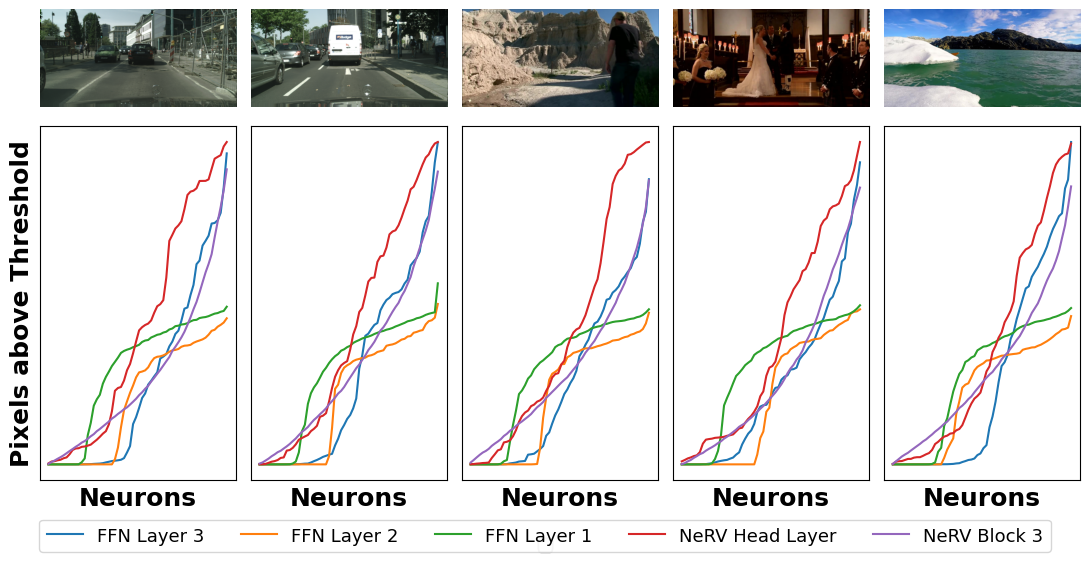

In [ ]:
# Different layout
vidnames = list(nerv_per_vid_num_pixels_with_meaningful_contrib.keys())

fig, axs = plt.subplots(2, len(vidnames), figsize=(11, 6), tight_layout=True, gridspec_kw={'width_ratios': [1, 1,1, 1,1], 'height_ratios':[1,1.5]})
titles_fontsize = 18


selected_thresh = 0.01

for vid_idx, vidname in enumerate(vidnames):

    if vidname in cityscapes_vids:
        dataset_name = "cityscapes"
    elif vidname in vipseg_vids:
        dataset_name = "vipseg"
    rgb_img = read_image(get_first_rgb_img_frame(vidname, dataset_name))
    if vidname in vipseg_vids:
        rgb_img = transforms.CenterCrop((640, 1280))(rgb_img)
                    
    axs[0][vid_idx].imshow(rgb_img.permute(1,2,0).numpy())
    # axs[0][vid_idx].set_title('Ground Truth Image', fontsize=titles_fontsize)
    

    # For each sorted contrib vector, sample equally spaced points to get 60 from each
    # Sample 60 equally spaced points from each tensor
    num_samples = 60
    
    nerv_head = nerv_per_vid_num_pixels_with_meaningful_contrib[vidname]["head"]
    nerv_blk_3 = nerv_per_vid_num_pixels_with_meaningful_contrib[vidname]["blk_3"]
    mlp_layer_1 = mlp_per_vid_num_pixels_with_meaningful_contrib[vidname]["layer_1"]
    mlp_layer_2 = mlp_per_vid_num_pixels_with_meaningful_contrib[vidname]["layer_2"]
    mlp_layer_3 = mlp_per_vid_num_pixels_with_meaningful_contrib[vidname]["layer_3"]

    # Stretch/squish all tensors to equal length        
    # Resample each tensor to the common length using linear interpolation
    nerv_head = F.interpolate(nerv_head.float().unsqueeze(0).unsqueeze(0), size=num_samples, mode='linear', align_corners=False).squeeze(0).squeeze(0)        
    nerv_blk_3 = F.interpolate(nerv_blk_3.float().unsqueeze(0).unsqueeze(0), size=num_samples, mode='linear', align_corners=False).squeeze(0).squeeze(0)        
    mlp_layer_1 = F.interpolate(mlp_layer_1.float().unsqueeze(0).unsqueeze(0), size=num_samples, mode='linear', align_corners=False).squeeze(0).squeeze(0)        
    mlp_layer_2 = F.interpolate(mlp_layer_2.float().unsqueeze(0).unsqueeze(0), size=num_samples, mode='linear', align_corners=False).squeeze(0).squeeze(0)        
    mlp_layer_3 = F.interpolate(mlp_layer_3.float().unsqueeze(0).unsqueeze(0), size=num_samples, mode='linear', align_corners=False).squeeze(0).squeeze(0)
    
    axs[1][vid_idx].plot(mlp_layer_3, label='FFN Layer 3', color='tab:blue')
    axs[1][vid_idx].plot(mlp_layer_2, label='FFN Layer 2', color='tab:orange')
    axs[1][vid_idx].plot(mlp_layer_1, label='FFN Layer 1', color='tab:green')
    
    axs[1][vid_idx].plot(nerv_head, label='NeRV Head Layer', color='tab:red')
    axs[1][vid_idx].plot(nerv_blk_3, label='NeRV Block 3', color='tab:purple')

    
    axs[1][vid_idx].set_xlabel("Neurons", fontsize=titles_fontsize, fontweight='bold')
        
    axs[0][vid_idx].axis('off')
    
    axs[1][0].set_ylabel("Pixels above Threshold", fontsize=titles_fontsize, fontweight='bold')
    
    for vid_idx in range(len(vidnames)):
        axs[1][vid_idx].set_yticks([])
        axs[1][vid_idx].set_yticklabels([])
        axs[1][vid_idx].set_xticks([])
        axs[1][vid_idx].set_xticklabels([])
        
        # axs[1][vid_idx].grid()

    handles, labels = axs[1][vid_idx].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.06), fontsize=13) #prop={'weight': 'bold'})

## Save figure

In [ ]:
os.makedirs('../outputs/supplementary', exist_ok=True)
fig.savefig('../outputs/supplementary/4.2-pixels_per_neuron.pdf', bbox_inches="tight", pad_inches=0.05)

# Fig 2 - Neurons per pixel

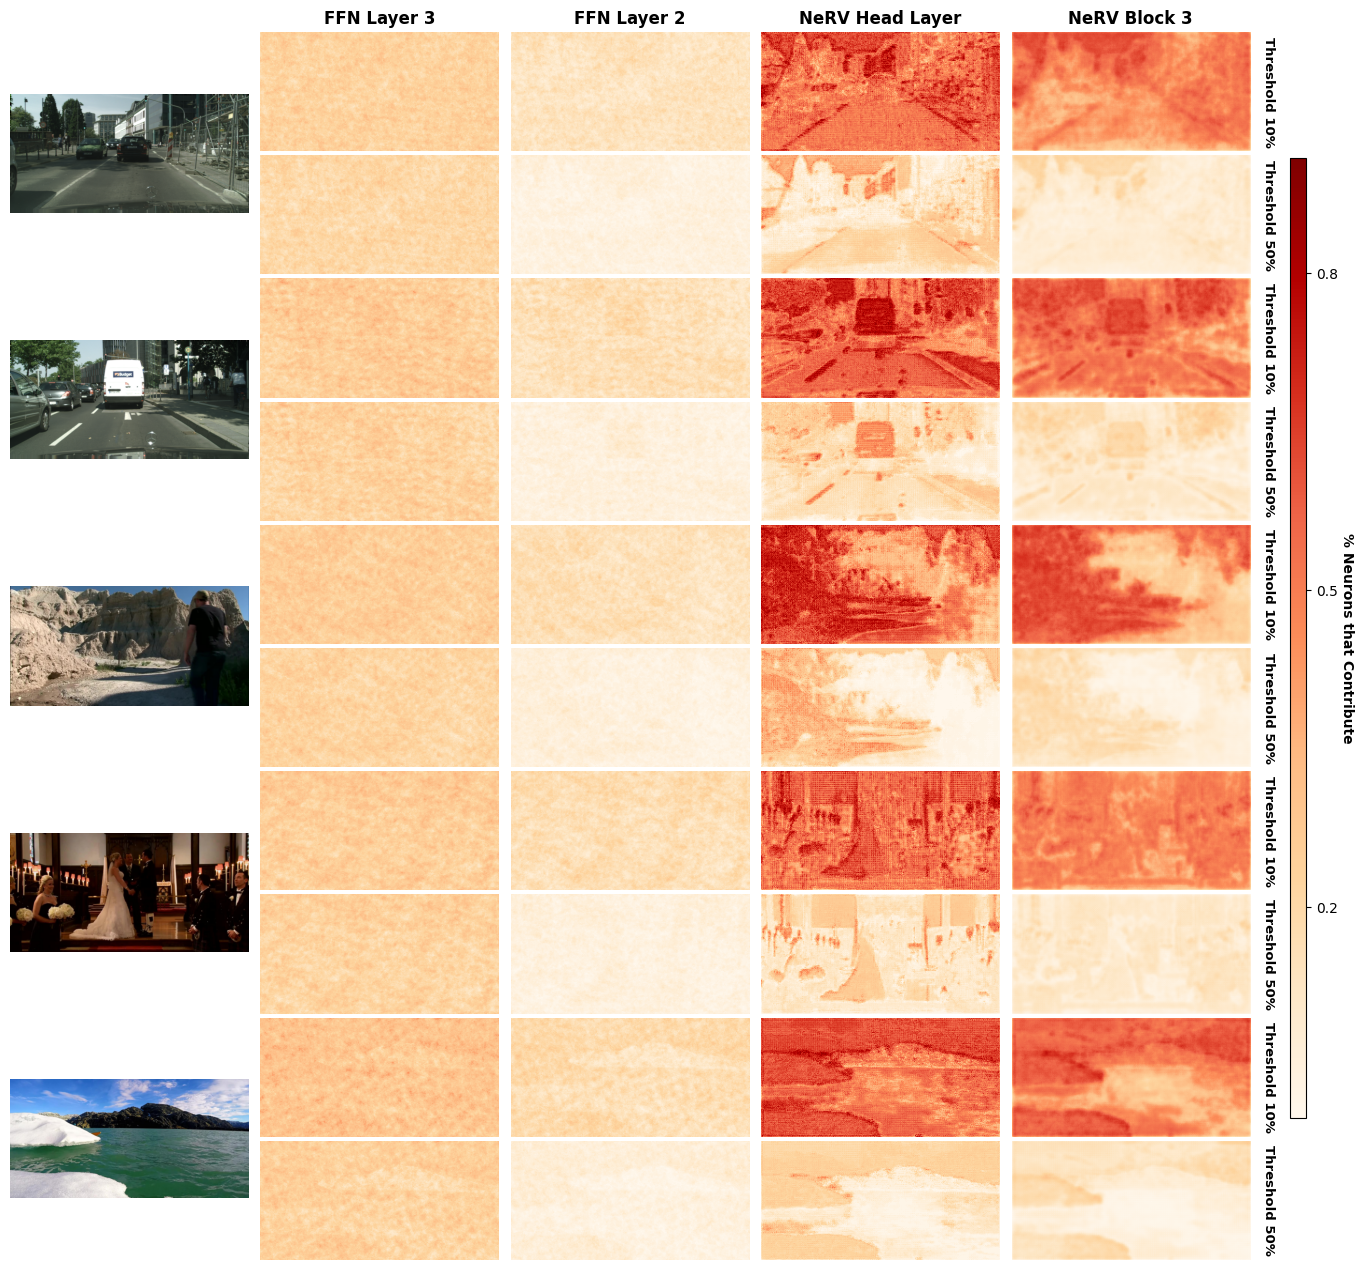

In [14]:
vidnames = list(nerv_per_vid_num_pixels_with_meaningful_contrib.keys())


target_areas = [0.1, 0.5]
titles_fontsize = 12


# Set up gridspec
fig = plt.figure(figsize=(16, 16))#, tight_layout=True)
gs = gridspec.GridSpec(2*len(vidnames), 5, width_ratios=[1, 1, 1, 1, 1])

for vid_idx, vidname in enumerate(vidnames):

    # Plot the RGB image at the center of the first column
    if vidname in cityscapes_vids:
            dataset_name = "cityscapes"
    elif vidname in vipseg_vids:
        dataset_name = "vipseg"
    rgb_img = read_image(get_first_rgb_img_frame(vidname, dataset_name))
    
    if vidname in vipseg_vids:
        rgb_img = transforms.CenterCrop((640, 1280))(rgb_img)
    
    rgb_ax = fig.add_subplot(gs[vid_idx*2:(vid_idx+1)*2, 0])
    rgb_ax.imshow(rgb_img.permute(1, 2, 0).numpy())
    rgb_ax.axis('off')

    for target_area_idx, target_area in enumerate(target_areas):
        head_heatmap = nerv_per_vid_num_kernels_with_meaningful_contrib[vidname][target_area]["head"]
        blk_3_heatmap = nerv_per_vid_num_kernels_with_meaningful_contrib[vidname][target_area]["blk_3"]
        layer_1_heatmap = mlp_per_vid_num_kernels_with_meaningful_contrib[vidname][target_area]["layer_1"]
        layer_2_heatmap = mlp_per_vid_num_kernels_with_meaningful_contrib[vidname][target_area]["layer_2"]
        layer_3_heatmap = mlp_per_vid_num_kernels_with_meaningful_contrib[vidname][target_area]["layer_3"]

        if target_area_idx == 0:
            vmin = min(head_heatmap.min(), blk_3_heatmap.min(), layer_1_heatmap.min(), layer_2_heatmap.min(), layer_3_heatmap.min())
            vmax = max(head_heatmap.max(), blk_3_heatmap.max(), layer_1_heatmap.max(), layer_2_heatmap.max(), layer_3_heatmap.max())
        else:
            vmin = min(vmin, head_heatmap.min(), blk_3_heatmap.min(), layer_1_heatmap.min(), layer_2_heatmap.min(), layer_3_heatmap.min())
            vmax = max(vmax, head_heatmap.max(), blk_3_heatmap.max(), layer_1_heatmap.max(), layer_2_heatmap.max(), layer_3_heatmap.max())
            
    # Plot other images in the remaining columns
    for target_area_idx, target_area in enumerate(target_areas):
        axs = [fig.add_subplot(gs[(vid_idx*2) + target_area_idx, col_idx]) for col_idx in range(1, 5)]

        head_heatmap = nerv_per_vid_num_kernels_with_meaningful_contrib[vidname][target_area]["head"]
        blk_3_heatmap = nerv_per_vid_num_kernels_with_meaningful_contrib[vidname][target_area]["blk_3"]
        layer_1_heatmap = mlp_per_vid_num_kernels_with_meaningful_contrib[vidname][target_area]["layer_1"]
        layer_2_heatmap = mlp_per_vid_num_kernels_with_meaningful_contrib[vidname][target_area]["layer_2"]
        layer_3_heatmap = mlp_per_vid_num_kernels_with_meaningful_contrib[vidname][target_area]["layer_3"]
        
        im = axs[0].imshow(layer_3_heatmap, cmap="OrRd", vmin=vmin, vmax=vmax) # GnBu
        im = axs[1].imshow(layer_2_heatmap, cmap="OrRd", vmin=vmin, vmax=vmax)
        im = axs[2].imshow(head_heatmap, cmap="OrRd", vmin=vmin, vmax=vmax)
        im = axs[3].imshow(blk_3_heatmap, cmap="OrRd",vmin=vmin, vmax=vmax)

        if vid_idx == 0 and target_area_idx == 0:
            axs[0].set_title(f'FFN Layer 3', fontsize=titles_fontsize, fontweight='bold')
            axs[1].set_title(f'FFN Layer 2', fontsize=titles_fontsize, fontweight='bold')
            axs[2].set_title(f'NeRV Head Layer', fontsize=titles_fontsize, fontweight='bold')
            axs[3].set_title(f'NeRV Block 3', fontsize=titles_fontsize, fontweight='bold')

        axs[-1].text(1.05, 0.5, f"Threshold {int(target_area * 100)}%", fontsize=9.5, transform=axs[-1].transAxes, rotation=-90,
                    verticalalignment='center', horizontalalignment='left', fontweight='bold')

        for ax in axs:
            ax.axis('off')

#plt.subplots_adjust(wspace=0.05, hspace=-0.05)
fig.subplots_adjust(right=0.9)
cbar_ax_magma = fig.add_axes([0.925, 0.2, 0.01, 0.6])
cbar_magma = fig.colorbar(im, cax=cbar_ax_magma, cmap='OrRd', orientation='vertical', pad=0.02, aspect=50, ticks=[0.2, 0.5, 0.8])
cbar_magma.ax.set_yticklabels(['0.2', '0.5', '0.8'])
cbar_magma.set_label('% Neurons that Contribute', rotation=270, labelpad=12, fontweight='bold')

plt.subplots_adjust(wspace=0.05, hspace=-0.15)


In [15]:
os.makedirs('../outputs/supplementary/', exist_ok=True)
fig.savefig('../outputs/supplementary/neurons_per_pixel.pdf', bbox_inches="tight", pad_inches=0)